In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(".data/bot_detection_data.csv")
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   User ID         50000 non-null  int64
 1   Username        50000 non-null  str  
 2   Tweet           50000 non-null  str  
 3   Retweet Count   50000 non-null  int64
 4   Mention Count   50000 non-null  int64
 5   Follower Count  50000 non-null  int64
 6   Verified        50000 non-null  bool 
 7   Bot Label       50000 non-null  int64
 8   Location        50000 non-null  str  
 9   Created At      50000 non-null  str  
 10  Hashtags        41659 non-null  str  
dtypes: bool(1), int64(5), str(5)
memory usage: 3.9 MB


,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,NaN
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,foreign mention


Shape: (50000, 11)

Columns and dtypes:
 User ID                    int64
Username                     str
Tweet                        str
Retweet Count              int64
Mention Count              int64
Follower Count             int64
Verified                    bool
Bot Label                  int64
Location                     str
Created At        datetime64[us]
Hashtags                     str
dtype: object

Missing values:
 User ID              0
Username             0
Tweet                0
Retweet Count        0
Mention Count        0
Follower Count       0
Verified             0
Bot Label            0
Location             0
Created At           0
Hashtags          8341
dtype: int64

Unique counts (selected):
  User IDs: 50000
  Usernames: 40566
  Locations: 25199
  Hashtags (non-null): 41659

Numeric summary:
                   count        mean          std  min      25%     50%  \
Retweet Count   50000.0    50.00560    29.181160  0.0    25.00    50.0   
Mention Count   500

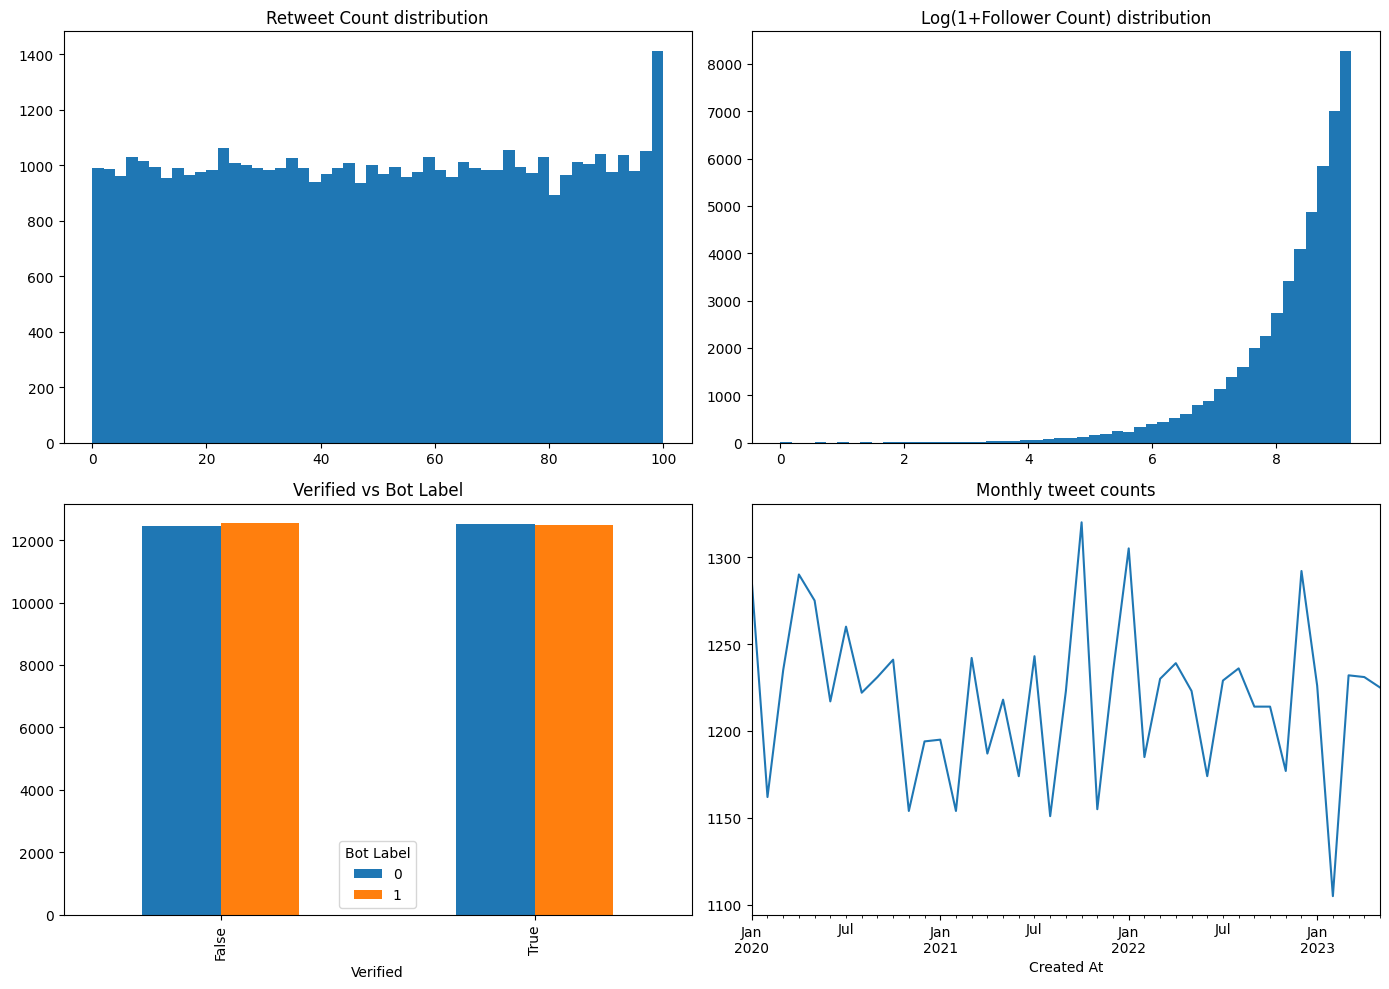

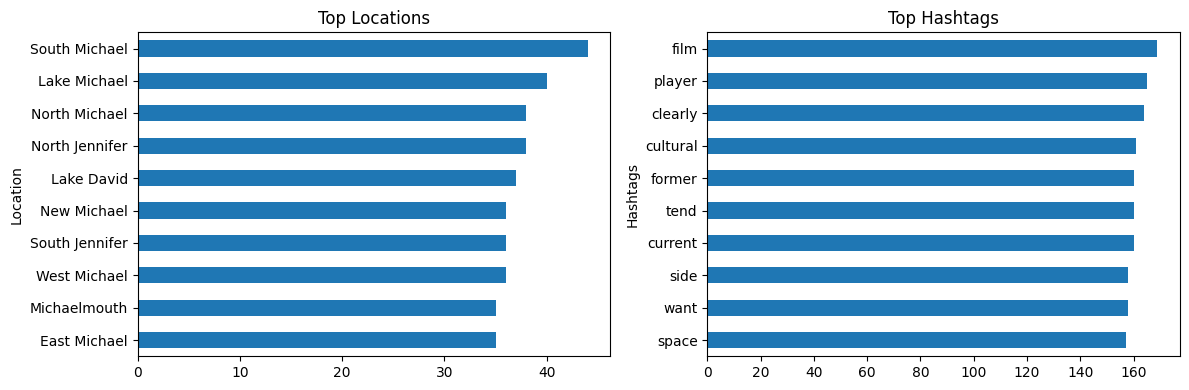

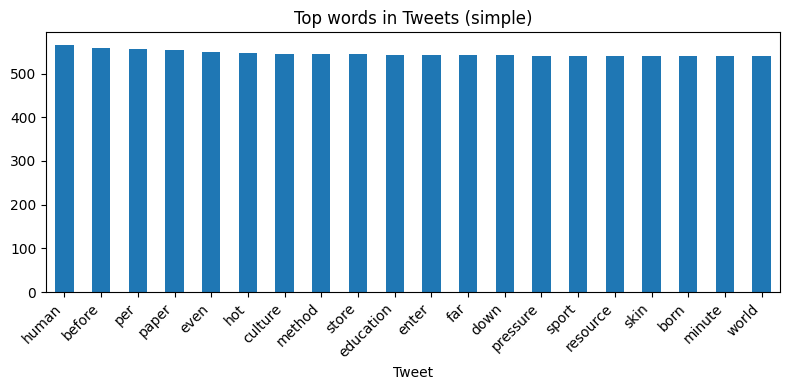

{'shape': (50000, 11),
 'dtypes': User ID                    int64
 Username                     str
 Tweet                        str
 Retweet Count              int64
 Mention Count              int64
 Follower Count             int64
 Verified                    bool
 Bot Label                  int64
 Location                     str
 Created At        datetime64[us]
 Hashtags                     str
 dtype: object,
 'missing': User ID              0
 Username             0
 Tweet                0
 Retweet Count        0
 Mention Count        0
 Follower Count       0
 Verified             0
 Bot Label            0
 Location             0
 Created At           0
 Hashtags          8341
 dtype: int64,
 'numeric_summary':                   count        mean          std  min      25%     50%  \
 Retweet Count   50000.0    50.00560    29.181160  0.0    25.00    50.0   
 Mention Count   50000.0     2.51376     1.708563  0.0     1.00     3.0   
 Follower Count  50000.0  4988.60238  2878.

In [10]:
import re

# Quick EDA summary and plots for df

# Basic overview
print("Shape:", df.shape)
print("\nColumns and dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nUnique counts (selected):")
print("  User IDs:", df['User ID'].nunique())
print("  Usernames:", df['Username'].nunique())
print("  Locations:", df['Location'].nunique())
print("  Hashtags (non-null):", df['Hashtags'].notna().sum())

# Descriptive statistics
print("\nNumeric summary:\n", df[['Retweet Count', 'Mention Count', 'Follower Count']].describe().T)
print("\nCategorical summary (top values):")
print("Verified:\n", df['Verified'].value_counts(dropna=False))
print("Bot Label:\n", df['Bot Label'].value_counts(dropna=False))

# Ensure datetime
df['Created At'] = pd.to_datetime(df['Created At'], errors='coerce')

# Time-based counts
time_counts = df.set_index('Created At').resample('ME').size()

# Top locations and hashtags
top_locations = df['Location'].fillna("Unknown").value_counts().head(10)
top_hashtags = (df['Hashtags'].dropna()
                    .str.split()
                    .explode()
                    .value_counts()
                    .head(10))

# Top words from tweets (simple tokenization, small stoplist)
stopwords = {"the","and","a","to","of","in","is","for","on","that","it","this","with","as","are","was","be","have","but","or","by","an","at"}
tweets_text = df['Tweet'].dropna().str.lower()
words = tweets_text.str.findall(r"\b[a-z]{2,}\b").explode()
words = words[~words.isin(stopwords)]
top_words = words.value_counts().head(20)

# Plots
plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
plt.hist(df['Retweet Count'].dropna(), bins=50)
plt.title('Retweet Count distribution')

plt.subplot(2,2,2)
plt.hist(np.log1p(df['Follower Count'].dropna()), bins=50)
plt.title('Log(1+Follower Count) distribution')

plt.subplot(2,2,3)
pd.crosstab(df['Verified'], df['Bot Label']).plot(kind='bar', stacked=False, ax=plt.gca())
plt.title('Verified vs Bot Label')

plt.subplot(2,2,4)
time_counts.plot(ax=plt.gca())
plt.title('Monthly tweet counts')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
top_locations.plot(kind='barh')
plt.title('Top Locations')
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
top_hashtags.plot(kind='barh')
plt.title('Top Hashtags')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
top_words.plot(kind='bar')
plt.title('Top words in Tweets (simple)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Return summary objects for further inspection if needed
eda_summary = {
    "shape": df.shape,
    "dtypes": df.dtypes,
    "missing": df.isnull().sum(),
    "numeric_summary": df[['Retweet Count', 'Mention Count', 'Follower Count']].describe().T,
    "verified_counts": df['Verified'].value_counts(dropna=False),
    "bot_label_counts": df['Bot Label'].value_counts(dropna=False),
    "monthly_counts": time_counts,
    "top_locations": top_locations,
    "top_hashtags": top_hashtags,
    "top_words": top_words
}
eda_summary